In [95]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [96]:
# --- PREP WORK ---
# X being our Macro/Market indicators and y our Protfolio and Factor Betas
# We align X and y, lagging X by 0 period since our Betas are optimal in hindsight
df_target_betas=pd.read_csv('optimal_betas.csv')

# 1. Set the 'Unnamed: 0' column as the actual index
df_target_betas = df_target_betas.set_index('Unnamed: 0')

# 2. Convert the new index to proper Pandas datetime objects
df_target_betas.index = pd.to_datetime(df_target_betas.index)

# 3. Clean up the index name (optional, but good for neatness)
df_target_betas.index.name = 'Date'

macr_df=pd.read_csv('Macro_Market_Indicators.csv')

# 1. Convert Date columns to standard datetime objects
# Note: format='%b-%y' handles the 'Jan-00' style in your macro image
macr_df['Date'] = pd.to_datetime(macr_df['Date'], format='%b-%y', errors='coerce')
df_target_betas.index = pd.to_datetime(df_target_betas.index)

# 2. Set the Date as index for the macro data
macr_df = macr_df.set_index('Date').sort_index()

# 3. THE FIX: Reindex X to match y's quarterly dates
# we use 'ffill' (forward fill) to ensure we use the most recent macro 
# data available AT the time of the rebalance.
X_aligned = macr_df.reindex(df_target_betas.index, method='ffill')

# 4. Final Cleanup: Drop any rows where macro data didn't exist yet (early 2000s)
y_aligned = df_target_betas.loc[X_aligned.dropna(how='all').index]
X_aligned = X_aligned.dropna(how='all')

print(f"Alignment Complete. X shape: {X_aligned.shape}, y shape: {y_aligned.shape}")


Alignment Complete. X shape: (63, 43), y shape: (63, 7)


In [102]:
# --- SPLITTING THE TIMELINE ---
train_test_mask = (y_aligned.index >= '2004-01-01') & (y_aligned.index <= '2017-12-31')
oos_mask = (y_aligned.index >= '2018-01-01') & (y_aligned.index <= '2019-12-31')

X_train_test = X_aligned.loc[train_test_mask]
y_train_test = y.loc[train_test_mask]

X_oos = X_aligned.loc[oos_mask]
y_oos = y.loc[oos_mask]


In [103]:
# 1. Set the 'Unnamed: 0' column as the actual index
y_oos = y_oos.set_index('Unnamed: 0')

# 2. Convert the new index to proper Pandas datetime objects
y_oos.index = pd.to_datetime(y_oos.index)

# 3. Clean up the index name (optional, but good for neatness)
y_oos.index.name = 'Date'

In [104]:
# 1. Force X and y to only keep numeric columns (dropping any stray date strings)
X_train_test = X_train_test.select_dtypes(include=[np.number])
y_train_test = y_train_test.select_dtypes(include=[np.number])

# Do the same for the Out-Of-Sample data so it doesn't crash later!
X_oos = X_oos.select_dtypes(include=[np.number])
y_oos = y_oos.select_dtypes(include=[np.number])

# 2. Just in case 'Unnamed: 0' snuck through as a weird numeric type, drop it explicitly
if 'Unnamed: 0' in y_train_test.columns:
    y_train_test = y_train_test.drop(columns=['Unnamed: 0'])
if 'Unnamed: 0' in y_oos.columns:
    y_oos = y_oos.drop(columns=['Unnamed: 0'])

# 3. Retrain the model
model.fit(X_train_test, y_train_test)

print(f"Success! Model Trained on {len(X_train_test)} quarters.")

Success! Model Trained on 56 quarters.


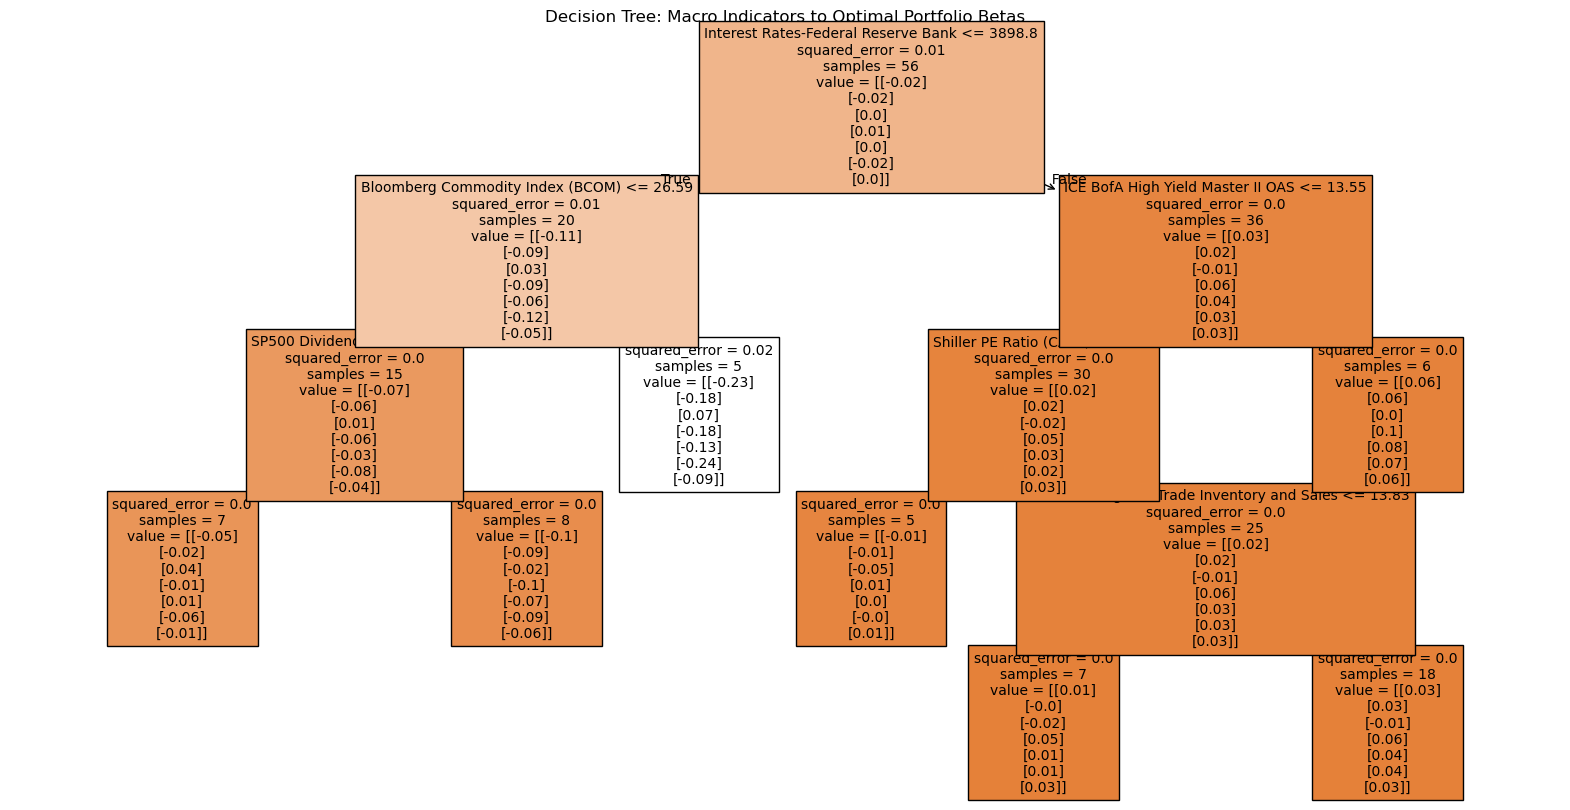

In [105]:
# Then we visualize the Macro Intuition
plt.figure(figsize=(20,10))
plot_tree(model, 
          feature_names=features.columns, 
          filled=True, 
          fontsize=10, 
          precision=2)
plt.title("Decision Tree: Macro Indicators to Optimal Portfolio Betas")
plt.show()

OOS RMSE for Port_Beta_MSCI USA: 0.0383
OOS RMSE for Port_Beta_MSCI USA Value: 0.0361
OOS RMSE for Port_Beta_MSCI USA Low Size: 0.0373
OOS RMSE for Port_Beta_MSCI USA Low Volatility: 0.0713
OOS RMSE for Port_Beta_MSCI USA High Dividend Yield: 0.0417
OOS RMSE for Port_Beta_MSCI USA Quality: 0.0397
OOS RMSE for Port_Beta_MSCI USA Momentum: 0.0405


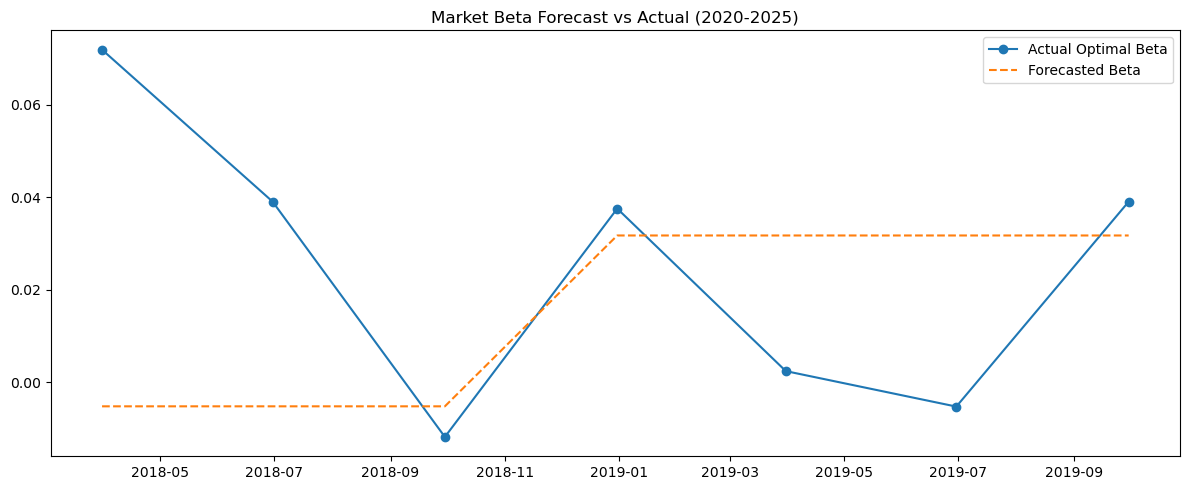

In [106]:
# 1. Generate Predictions using the cleaned column names
y_pred_oos = pd.DataFrame(
    model.predict(X_oos), 
    index=X_oos.index, 
    columns=y_train_test.columns  # <-- THE FIX: use the exact columns the model trained on
)

# 2. Quick Accuracy Check (also iterating over the cleaned columns)
for col in y_train_test.columns:
    # Ensure y_oos also drops the ghost column if it hasn't already
    if 'Unnamed: 0' in y_oos.columns:
        y_oos = y_oos.drop(columns=['Unnamed: 0'])
        
    rmse = np.sqrt(mean_squared_error(y_oos[col], y_pred_oos[col]))
    print(f"OOS RMSE for {col}: {rmse:.4f}")

# 3. Plotting Predicted vs Actual for Market Beta
plt.figure(figsize=(12,5))
plt.plot(y_oos.index, y_oos['Port_Beta_MSCI USA'], label='Actual Optimal Beta', marker='o')
plt.plot(y_pred_oos.index, y_pred_oos['Port_Beta_MSCI USA'], label='Forecasted Beta', linestyle='--')
plt.title("Market Beta Forecast vs Actual (2020-2025)")
plt.legend()
plt.tight_layout()
plt.show()

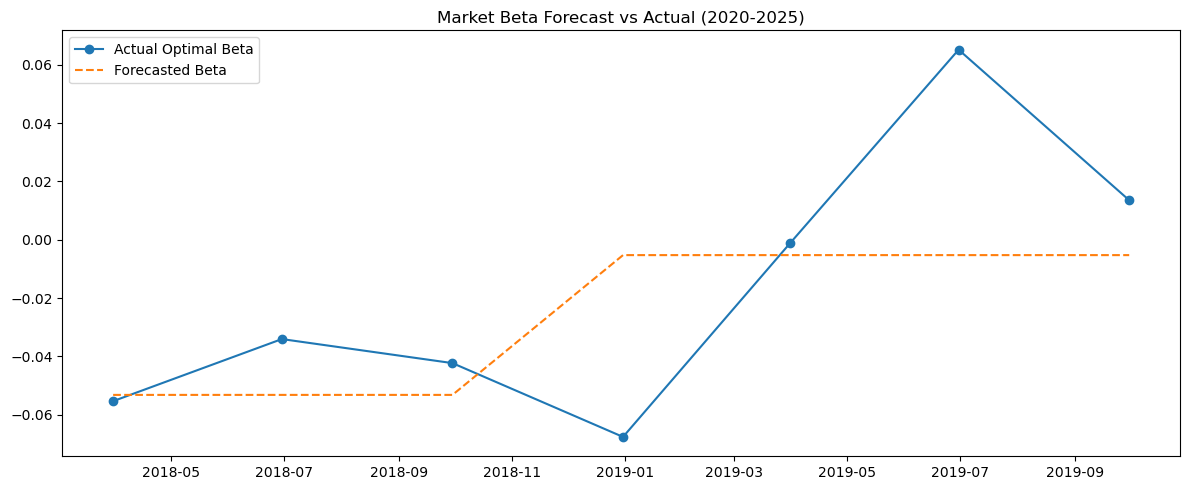

In [107]:
# 3. Plotting Predicted vs Actual for Market Beta
plt.figure(figsize=(12,5))
plt.plot(y_oos.index, y_oos['Port_Beta_MSCI USA Low Size'], label='Actual Optimal Beta', marker='o')
plt.plot(y_pred_oos.index, y_pred_oos['Port_Beta_MSCI USA Low Size'], label='Forecasted Beta', linestyle='--')
plt.title("Market Beta Forecast vs Actual (2020-2025)")
plt.legend()
plt.tight_layout()
plt.show()

In [108]:
# Now let's validate on 2020 to 2025
X_oos_monthly=pd.read_csv('Validation Dataset.csv')

# 1. EXORCISE THE 1970 INDEX: Reset the index and completely drop the 1970 ghost dates
X_oos_monthly = X_oos_monthly.reset_index(drop=True)

# 2. FIX THE REAL DATES: Convert the actual 'Date' column and make it the true index
if 'Date' in X_oos_monthly.columns:
    X_oos_monthly['Date'] = pd.to_datetime(X_oos_monthly['Date'])
    X_oos_monthly = X_oos_monthly.set_index('Date')

# 3. PURGE STRINGS: Keep only numeric data (This automatically drops lingering 'Date' strings)
X_oos_monthly = X_oos_monthly.select_dtypes(include=[np.number])

# 4. DOWNSAMPLE: Now that the index is definitely 2020-2025, resample to quarters
X_oos_quarterly = X_oos_monthly.resample('Q').last()

# 5. THE ULTIMATE ALIGNMENT: .reindex() is a magic bullet. 
# It forcefully reshapes the dataframe to match the model's exact features.
# It automatically drops extra columns (like Market-to-Book) AND adds missing columns as NaNs!
expected_features = model.feature_names_in_
X_oos_aligned = X_oos_quarterly.reindex(columns=expected_features)

# 6. FILL GAPS: Forward fill any NaNs created by missing columns so the model doesn't crash
X_oos_aligned = X_oos_aligned.ffill().bfill()

# 7. PREDICT
y_pred_oos = pd.DataFrame(
    model.predict(X_oos_aligned), 
    index=X_oos_aligned.index, 
    columns=y_train_test.columns
)

print(f"Index cleanly set from {X_oos_aligned.index.min().date()} to {X_oos_aligned.index.max().date()}")
print(f"Features aligned perfectly: {len(X_oos_aligned.columns)} columns.")


Index cleanly set from 2020-03-31 to 2025-12-31
Features aligned perfectly: 42 columns.


C:\Users\Anas\AppData\Local\Temp\ipykernel_24264\3123383422.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_oos_monthly['Date'] = pd.to_datetime(X_oos_monthly['Date'])
C:\Users\Anas\AppData\Local\Temp\ipykernel_24264\3123383422.py:16: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  X_oos_quarterly = X_oos_monthly.resample('Q').last()


In [109]:
y_pred_oos

,Port_Beta_MSCI USA,Port_Beta_MSCI USA Value,Port_Beta_MSCI USA Low Size,Port_Beta_MSCI USA Low Volatility,Port_Beta_MSCI USA High Dividend Yield,Port_Beta_MSCI USA Quality,Port_Beta_MSCI USA Momentum
Date,,,,,,,
2020-03-31,0.060534,0.059404,0.001253,0.100818,0.077312,0.068380,0.060922
2020-06-30,0.060534,0.059404,0.001253,0.100818,0.077312,0.068380,0.060922
2020-09-30,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657
2020-12-31,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657
2021-03-31,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657
2021-06-30,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657
2021-09-30,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657
2021-12-31,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657
2022-03-31,0.031753,0.029743,-0.005281,0.060313,0.041353,0.038026,0.033657


In [88]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd

# 1. Define the grid of parameters tailored for a single Decision Tree
param_grid_dt = {
    # Letting the tree grow deeper (6, 8, 10) gives it permission to find more complex macro patterns
    'max_depth': [4, 6, 8, 10, None],        
    # Lowering the minimum samples allows it to create more specific "regimes"
    'min_samples_leaf': [1, 2, 4, 6],        
    # Minimum data points needed in a node before it's allowed to split again
    'min_samples_split': [2, 5, 10]          
}

# 2. Set up the Base Model and the Grid Searcher
base_dt = DecisionTreeRegressor(random_state=42)

# cv=3 cross-validates the historical data to ensure we don't overfit
grid_search_dt = GridSearchCV(
    estimator=base_dt, 
    param_grid=param_grid_dt, 
    cv=3, 
    n_jobs=-1, 
    scoring='neg_mean_squared_error' 
)

# 3. Train all the combinations and find the absolute best one
print("Testing different Decision Tree depths... \n")
grid_search_dt.fit(X_train_test, y_train_test) # Using your cleaned 2004-2019 data

# 4. Extract the optimized model
optimized_dt_model = grid_search_dt.best_estimator_

print("=== Tuning Complete! ===")
print("Best Parameters Found:")
for key, value in grid_search_dt.best_params_.items():
    print(f" - {key}: {value}")

# 5. Generate the new, smarter predictions for 2014-2019
y_pred_oos_optimized = pd.DataFrame(
    optimized_dt_model.predict(X_oos), 
    index=X_oos.index, 
    columns=y_train_test.columns
)

print("\nOptimized Out-of-Sample Forecasts (2020-2025):")
display(y_pred_oos_optimized.head())

Testing different Decision Tree depths... 

=== Tuning Complete! ===
Best Parameters Found:
 - max_depth: 4
 - min_samples_leaf: 2
 - min_samples_split: 10

Optimized Out-of-Sample Forecasts (2020-2025):


,Port_Beta_MSCI USA,Port_Beta_MSCI USA Value,Port_Beta_MSCI USA Low Size,Port_Beta_MSCI USA Low Volatility,Port_Beta_MSCI USA High Dividend Yield,Port_Beta_MSCI USA Quality,Port_Beta_MSCI USA Momentum
Date,,,,,,,
2016-03-31,0.032804,0.028356,-0.001461,0.062091,0.040706,0.040909,0.041445
2016-06-30,0.032804,0.028356,-0.001461,0.062091,0.040706,0.040909,0.041445
2016-09-30,0.032804,0.028356,-0.001461,0.062091,0.040706,0.040909,0.041445
2016-12-31,0.032804,0.028356,-0.001461,0.062091,0.040706,0.040909,0.041445
2017-03-31,0.032804,0.028356,-0.001461,0.062091,0.040706,0.040909,0.041445
